# Training the Texas Forecast Model

In [22]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Path is from notebooks/ → data/processed
df = pd.read_csv("../data/processed/model_data_texas.csv", parse_dates=["Date"])

# Set Date as index and sort by time
df = df.set_index("Date").sort_index()

df.head()


,Texas,Texas_lag_1,Texas_lag_2,Texas_lag_3,Texas_lag_6,Texas_lag_12,Texas_lag_24,rolling_3,rolling_6,rolling_12,...,rolling_36,month,quarter,year,is_winter,is_summer,target,month_sin,month_cos,yoy_24
Date,,,,,,,,,,,,,,,,,,,,,
2003-12-01,293156.0,267757.0,281431.0,294294.0,296723.0,307430.0,300793.0,280781.333333,315742.833333,312104.500000,...,322949.194444,12.0,4.0,2003.0,1,0,293156.0,-2.449294e-16,1.000000e+00,-0.025390
2004-01-01,308056.0,293156.0,267757.0,281431.0,377943.0,344839.0,350229.0,289656.333333,304095.000000,309039.250000,...,321427.305556,1.0,1.0,2004.0,1,0,308056.0,5.000000e-01,8.660254e-01,-0.120415
2004-02-01,300833.0,308056.0,293156.0,267757.0,379876.0,320745.0,309217.0,300681.666667,290921.166667,307379.916667,...,320950.277778,2.0,1.0,2004.0,1,0,300833.0,8.660254e-01,5.000000e-01,-0.027114
2004-03-01,284762.0,300833.0,308056.0,293156.0,294294.0,306409.0,323520.0,297883.666667,289332.500000,305576.000000,...,319508.555556,3.0,1.0,2004.0,0,0,284762.0,1.000000e+00,6.123234e-17,-0.119801
2004-04-01,266451.0,284762.0,300833.0,308056.0,281431.0,274512.0,347110.0,284015.333333,286835.833333,304904.250000,...,317878.583333,4.0,2.0,2004.0,0,0,266451.0,8.660254e-01,-5.000000e-01,-0.232373


In [23]:
# Target
y = df["target"]

# All feature columns = everything except raw Texas + target
feature_cols = [c for c in df.columns if c not in ["Texas", "target"]]
X = df[feature_cols]

# X.head()
len(feature_cols), feature_cols


(20,
 ['Texas_lag_1',
  'Texas_lag_2',
  'Texas_lag_3',
  'Texas_lag_6',
  'Texas_lag_12',
  'Texas_lag_24',
  'rolling_3',
  'rolling_6',
  'rolling_12',
  'rolling_12_std',
  'rolling_24',
  'rolling_36',
  'month',
  'quarter',
  'year',
  'is_winter',
  'is_summer',
  'month_sin',
  'month_cos',
  'yoy_24'])

In [24]:
# Train-test split by date
split_date = "2024-01-01"

X_train = X.loc[:split_date].iloc[:-1]   # up to Dec-2020
y_train = y.loc[:split_date].iloc[:-1]

X_test = X.loc[split_date:]
y_test = y.loc[split_date:]

X_train.shape, X_test.shape


((241, 20), (18, 20))

In [25]:
# Baseline model: Naive forecast using 1 month lag
y_pred_naive = X_test["Texas_lag_1"]

base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_naive))
base_mae = mean_absolute_error(y_test, y_pred_naive)

base_rmse, base_mae

(49771.966469869134, 41969.5)

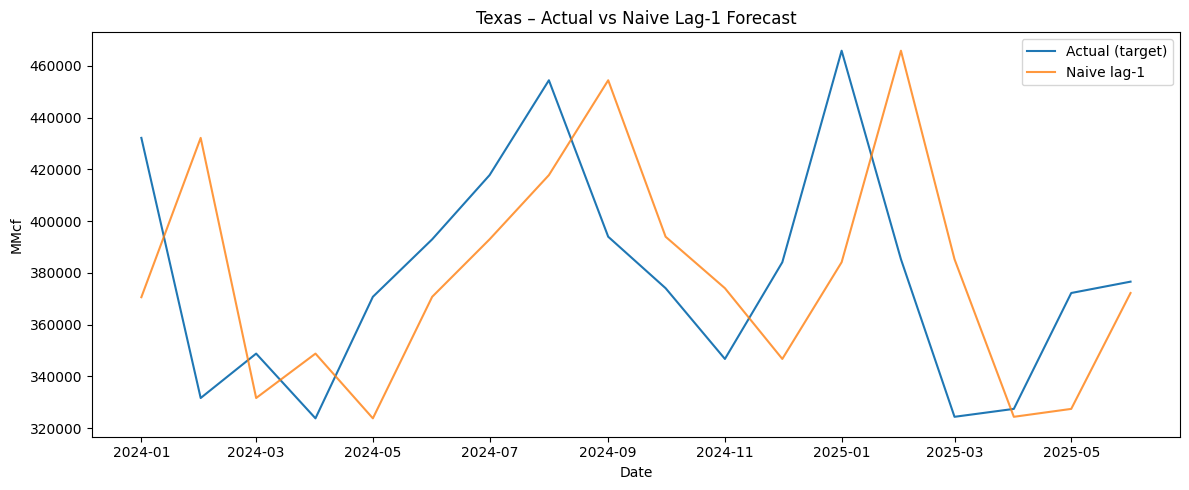

In [26]:
# Plot of actual vs. naive forecast
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label="Actual (target)")
plt.plot(y_test.index, y_pred_naive, label="Naive lag-1", alpha=0.8)
plt.title("Texas – Actual vs Naive Lag-1 Forecast")
plt.xlabel("Date")
plt.ylabel("MMcf")
plt.legend()
plt.tight_layout()
plt.show()


# LightGBM model to forecast Texas natural gas consumption

In [27]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt


In [28]:
# Create LightGBM datasets for training and validation
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test, label=y_test)

params = {
    "objective": "regression",
    "metric": "rmse",
    "num_leaves": 50,
    "learning_rate": 0.01,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "min_child_samples": 20,
    "lambda_l1": 1.0,
    "lambda_l2": 1.0,
}

# --- FIX: use callbacks for Early Stopping ---
callbacks = [
    lgb.early_stopping(stopping_rounds=50),
    lgb.log_evaluation(period=50)
]

model_lgb = lgb.train(
    params=params,
    train_set=train_data,
    num_boost_round=5000,
    valid_sets=[train_data, valid_data],
    valid_names=["train", "valid"],
    callbacks=callbacks,
)



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000478 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1131
[LightGBM] [Info] Number of data points in the train set: 241, number of used features: 20
[LightGBM] [Info] Start training from score 294347.431535
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [29]:
y_pred_lgb = model_lgb.predict(X_test)



In [30]:
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)

rmse_lgb, mae_lgb

(25368.072692712667, 17227.81454987988)

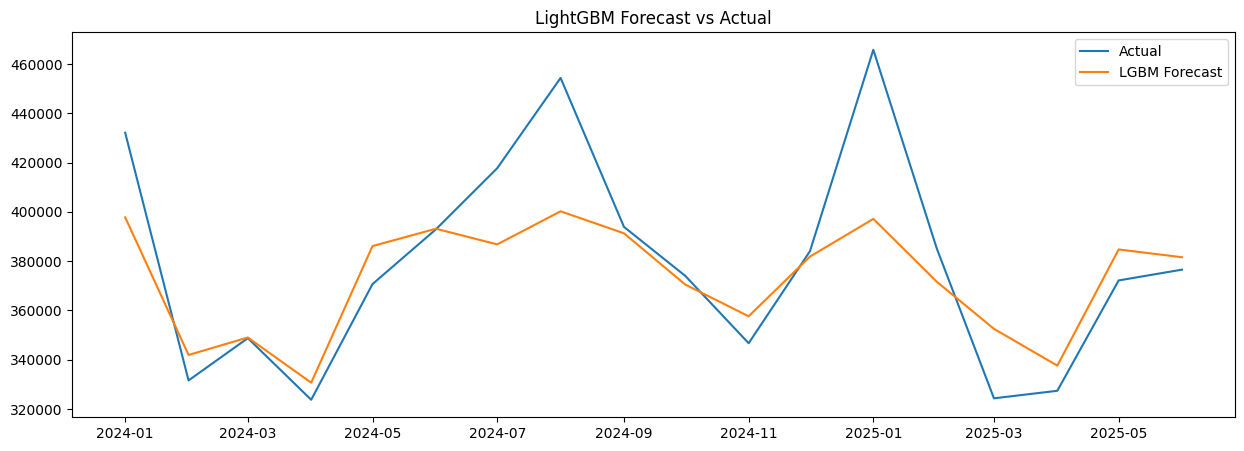

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred_lgb, label="LGBM Forecast")
plt.title("LightGBM Forecast vs Actual")
plt.legend()
plt.show()


<Figure size 800x600 with 0 Axes>

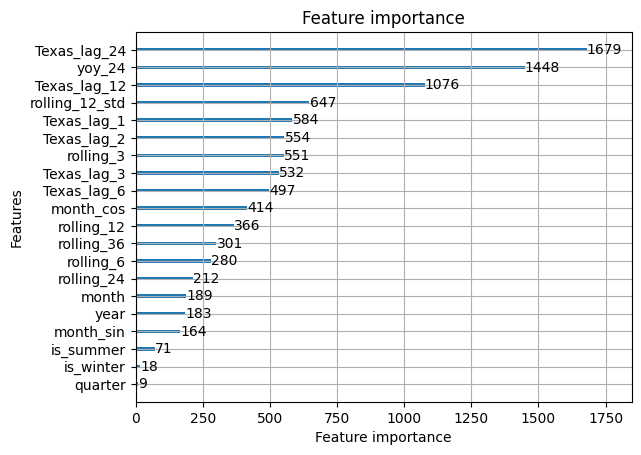

<Figure size 800x600 with 0 Axes>

In [32]:
lgb.plot_importance(model_lgb, max_num_features=20)
plt.figure(figsize=(8,6))